In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('/Users/wenduom/Desktop/ml/ml2026/makemore/names.txt', 'r').read().splitlines()

In [24]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)               
print(len(itos))

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [19]:
block_size = 3

X, Y = [], []
for w in words[:5]:
    context = [0] * block_size
    for c in w + '.':
        i = stoi[c]
        X.append(context)
        Y.append(i)        
        #print(''.join([itos[ii] for ii in context]) + ' --> ' + itos[i])
        context = context[1:] + [i]

        

X = torch.tensor(X)
Y = torch.tensor(Y)    

In [31]:
X.shape, Y.shape

(torch.Size([32, 3]), torch.Size([32]))

![mlp](3.png)

In [26]:
embed_dim = 2
C = torch.randn((27,2))

In [27]:
# plucking the embedding
C[5]

tensor([0.8884, 0.1417])

In [30]:
# another way of plucking the embedding
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([0.8884, 0.1417])

In [33]:
embed = C[X]
embed.shape

torch.Size([32, 3, 2])

In [43]:
w1 = torch.randn((3*2, 100))
b1 = torch.randn(100) 

In [36]:
embed[:, 0, :].shape

torch.Size([32, 2])

In [38]:
print(embed[:, 0, :].shape)
torch.cat([embed[:, 0, :], embed[:, 1, :], embed[:, 2, :]], 1).shape

torch.Size([32, 2])


torch.Size([32, 6])

In [40]:
torch.cat(torch.unbind(embed, 1), 1).shape

torch.Size([32, 6])

In [41]:
embed.view((32, 6)).shape

torch.Size([32, 6])

In [48]:
h = torch.tanh(embed.view(-1, 6) @ w1 + b1)
h.shape

torch.Size([32, 100])

In [49]:
w2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [51]:
logits = h @ w2 + b2
logits.shape

torch.Size([32, 27])

In [52]:
counts = logits.exp()

In [54]:
prob = counts/counts.sum(1, keepdim=True)
prob.shape

torch.Size([32, 27])

In [55]:
prob[torch.arange(32), Y]

tensor([2.2446e-13, 1.5141e-09, 2.2266e-03, 1.8327e-11, 6.7420e-09, 2.2892e-06,
        6.4996e-12, 6.6947e-15, 8.1800e-07, 3.6967e-16, 9.9243e-12, 4.8189e-03,
        1.4982e-17, 1.7214e-01, 8.6862e-12, 1.5104e-06, 3.3439e-19, 4.0915e-04,
        1.1228e-13, 1.0631e-13, 8.0254e-01, 2.2850e-09, 8.9928e-07, 1.8633e-05,
        3.5049e-06, 1.0218e-04, 3.6854e-09, 1.4267e-02, 5.3446e-07, 4.3415e-06,
        4.9320e-16, 2.7509e-04])

In [57]:
# negative log likelyhood
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(18.7709)

## Full code

In [59]:
block_size = 3

X, Y = [], []
for w in words:
    context = [0] * block_size
    for c in w + '.':
        i = stoi[c]
        X.append(context)
        Y.append(i)        
        #print(''.join([itos[ii] for ii in context]) + ' --> ' + itos[i])
        context = context[1:] + [i]

        

X = torch.tensor(X)
Y = torch.tensor(Y)    
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [85]:
C = torch.rand((27, 2))
W1 = torch.randn((6, 100))
B1 = torch.randn(100)
W2 = torch.randn((100, 27))
B2 = torch.randn(27)
parameters = [C, W1, B1, W2, B2]

In [63]:
C[X].shape

torch.Size([228146, 3, 2])

In [88]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre


In [86]:
for p in parameters:
    p.requires_grad = True

lri = []
lossi= []
for l in range(1000):

    # minibatch
    batch_size = 32
    ii = torch.randint(0, X.shape[0], (batch_size,))
    xs = X[ii]
    
    emb = C[xs].view(-1, 6)
    h = torch.tanh(emb @ W1 + B1) # (228146, 100)
    logits = h @ W2 + B2 # (228146, 27)
    loss = F.cross_entropy(logits, Y[ii])

    if l % 100 == 0:
        print(loss.item())  
    
    # reset grad
    for p in parameters:
        p.grad = None

    # back prop to compute the grad
    loss.backward()

    lr = lrs[l]

    # update the weight
    for p in parameters:
        p.data += -lr * p.grad

    lri.append(lre[l])
    lossi.append(loss.item())
    
    
  

14.830914497375488
7.267281532287598
6.640294551849365
4.759976387023926
3.5379676818847656
3.0494394302368164
2.9377212524414062
2.543978214263916
3.049058675765991
5.330821990966797


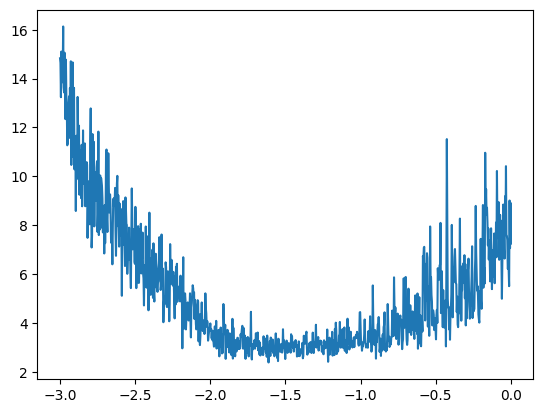

In [87]:
plt.plot(lri, lossi)

In [155]:
block_size = 6

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for c in w + '.':
            i = stoi[c]
            X.append(context)
            Y.append(i)        
            #print(''.join([itos[ii] for ii in context]) + ' --> ' + itos[i])
            context = context[1:] + [i]
                    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

    
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
    

torch.Size([182580, 6]) torch.Size([182580])
torch.Size([22740, 6]) torch.Size([22740])
torch.Size([22826, 6]) torch.Size([22826])


In [156]:
emb_dim = 12
C = torch.rand((27, emb_dim))
W1 = torch.randn((emb_dim*block_size, 300))
B1 = torch.randn(300)
W2 = torch.randn((300, 27))
B2 = torch.randn(27)
parameters = [C, W1, B1, W2, B2]

In [36]:
for p in parameters:
    p.requires_grad = True

ll = []
lossi= []
for l in range(100000):
    # minibatch
    batch_size = 32
    ii = torch.randint(0, Xtr.shape[0], (batch_size,))
    xs = Xtr[ii]
    
    emb = C[xs].view(-1, emb_dim*block_size)
    h = torch.tanh(emb @ W1 + B1) # (228146, 100)
    logits = h @ W2 + B2 # (228146, 27)
    loss = F.cross_entropy(logits, Ytr[ii])

    # reset grad
    for p in parameters:
        p.grad = None

    # back prop to compute the grad
    loss.backward()

    # update the weight
    for p in parameters:
        p.data += -0.01 * p.grad

    ll.append(l)
    lossi.append(loss.log10().item())
    
    

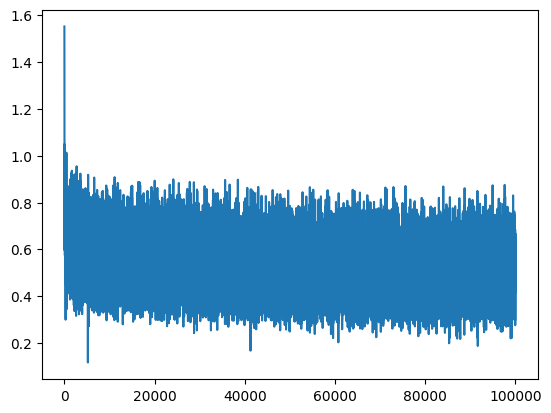

In [158]:
plt.plot(ll, lossi)

In [37]:
emb = C[Xdev].view(-1, emb_dim*block_size)
logits = torch.tanh(emb @ W1 + B1) @ W2 + B2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2372, grad_fn=<NllLossBackward0>)

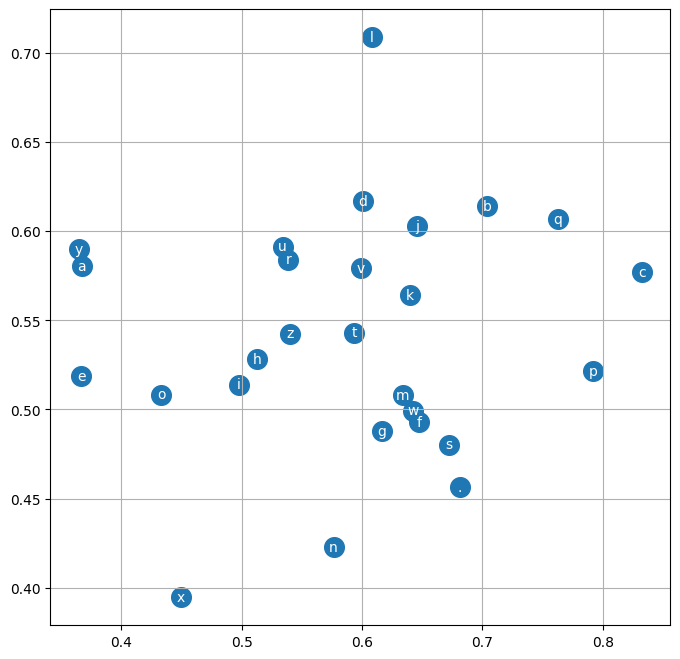

In [38]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)

for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
    
plt.grid('minor')    

In [41]:
# inference

for _ in range(20):
    out = []
    context = [0] * block_size    
    while True:
        emb = C[torch.tensor(context)]
        logits = torch.tanh(emb.view(-1, block_size*emb_dim) @ W1 + B1) @ W2 + B2        
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join([itos[i] for i in out]))        
        

saileni.
nimeja.
shanis.
amelah.
revaia.
killaoarne.
maraysi.
sydoanae.
zapfael.
jamdelinn.
curhahya.
zilay.
kistae.
marah.
niley.
ahbraptene.
tyevia.
rayble.
debr.
cinrolia.
